In [2]:
import pandas as pd
import statsmodels as sm
import altair as alt

## Data Cleaning

In [7]:
# Reading Data *** change to use package
marchmadness = pd.read_csv("../../data/clean/womensmarchmadness.csv")

# Review total rows
marchmadness.shape[0]

2092

In [8]:
# Removing NA but only in selected columns
marchmadness = marchmadness.dropna(subset=['seed', 'tourney_wins'])

# Notice no rows were removed
marchmadness.shape[0]

2092

In [11]:
marchmadness = marchmadness[marchmadness['seed'] != 0]

## EDA

In [17]:
alt.Chart(marchmadness).mark_bar().encode(
    x = alt.X('seed').title('Seed'),
    y = alt.Y('count()').title('Number of Teams')
).properties(title='Distribution of Tournament Seeds')

alt.Chart(...)

In [35]:
avg_per_seed = marchmadness.groupby(by='seed')['tourney_wins'].mean().reset_index()

alt.Chart(avg_per_seed).mark_bar().encode(
    x = alt.X('seed').title('Seed'),
    y = alt.Y('tourney_wins').title('Avg. Tourney Wins')
).properties(title='Average Tournament Wins by Seed',
            width = 500)

alt.Chart(...)

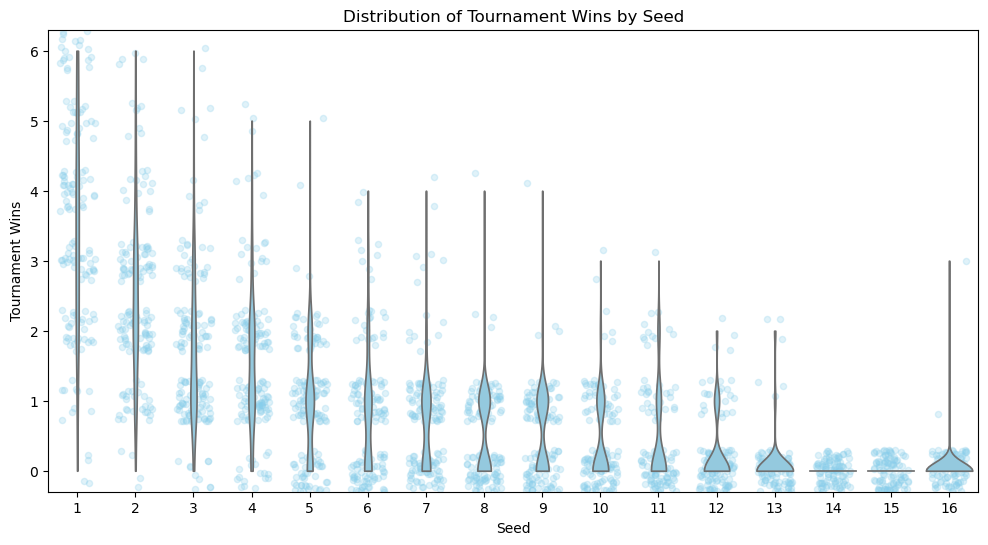

In [178]:
import numpy as np

plt.figure(figsize=(12, 6))

# Jitter plot
x_vals = marchmadness["seed"].astype("category").cat.codes
y_vals = marchmadness["tourney_wins"]
x_jitter = x_vals + np.random.uniform(-0.3, 0.3, size=len(x_vals))
y_jitter = y_vals + np.random.uniform(-0.3, 0.3, size=len(y_vals))

plt.scatter(x_jitter, y_jitter, alpha=0.25, color="skyblue", s=20)

# Violin plot
sns.violinplot(data=marchmadness, x="seed", y="tourney_wins", inner=None, color="skyblue", cut=0)

# Overall plot
plt.xticks(ticks=np.arange(len(marchmadness["seed"].unique())), 
           labels=sorted(marchmadness["seed"].unique()))
plt.xlabel("Seed")
plt.ylabel("Tournament Wins")
plt.title("Distribution of Tournament Wins by Seed")

plt.show()

In [191]:
jitter_plot = (
    alt.Chart(marchmadness).mark_circle(size=20, opacity=0.25).encode(
        x=alt.X('seed:N', title='Seed'),
        y=alt.Y('tourney_wins:N', title='Tournament Wins'),
        xOffset=alt.XOffset('jitterx:Q'),
        yOffset=alt.YOffset('jittery:Q')
    ).transform_calculate(
        # generate uniform jitter in range [-0.5, 0.5]
        jitterx='(random() - 0.5)',
        jittery='(random() - 0.5)'
    ).properties(
        title='Distribution of Tournament Wins by Seed'
    )
)

jitter_plot

alt.Chart(...)